In [1]:
from scipy.io import arff
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import os
import seaborn as sns
import matplotlib.pyplot as plt
import itables.interactive
import re


In [2]:
#Recebendo o dataset
data_path = os.path.join('C:\\Users\\mateu\\Arquivos de Programas Faculdade\\Repositorios\\DataMining-CRISP-DM-The-Nomao-Problem\\data\\processed', "nomao_2.csv")
data = pd.read_csv(data_path)

#Criando o DataFrame
df = pd.DataFrame(data)

#Visualizando 
print(df.head())

    V1    V2        V3        V4        V5        V6  V7    V8        V9  \
0  1.0  1.00  1.000000  1.000000  1.000000  1.000000   2  b'2'  0.860946   
1  1.0  0.75  0.857143  0.857143  0.894737  0.947368   2  b'1'  0.860946   
2  1.0  1.00  1.000000  1.000000  1.000000  1.000000   2  b'2'  0.860946   
3  1.0  0.75  0.857143  0.857143  0.842105  0.833333   2  b'1'  1.000000   
4  0.0  0.00  0.250000  0.000000  0.250000  0.000000   1  b'1'  0.860946   

       V10  ...      V111  V112      V113      V114      V115 V116  V117  \
0  0.82159  ...  0.500000     2  0.999953  0.777778  0.461538    2   1.0   
1  0.82159  ...  0.307692     2  0.999983  0.538462  0.437500    2   1.0   
2  0.82159  ...  0.461538     2  0.999993  0.800000  0.666667    2   1.0   
3  1.00000  ...  0.285714     2  0.998605  0.555556  0.384615    2   1.0   
4  0.82159  ...  0.396168     1  0.982576  0.644336  0.438054    1   1.0   

       V118      Class  Class_num  
0  1.000000  Duplicado          1  
1  1.000000  D

In [3]:
# 1) Lista de nomes oficiais para os atributos 2..119 (118 nomes)
doc_names = [
    "clean_name_intersect_min","clean_name_intersect_max",
    "clean_name_levenshtein_sim","clean_name_trigram_sim","clean_name_levenshtein_term","clean_name_trigram_term",
    "clean_name_including","clean_name_equality",
    "city_intersect_min","city_intersect_max","city_levenshtein_sim","city_trigram_sim","city_levenshtein_term","city_trigram_term","city_including","city_equality",
    "zip_intersect_min","zip_intersect_max","zip_levenshtein_sim","zip_trigram_sim","zip_levenshtein_term","zip_trigram_term","zip_including","zip_equality",
    "street_intersect_min","street_intersect_max","street_levenshtein_sim","street_trigram_sim","street_levenshtein_term","street_trigram_term","street_including","street_equality",
    "website_intersect_min","website_intersect_max","website_levenshtein_sim","website_trigram_sim","website_levenshtein_term","website_trigram_term","website_including","website_equality",
    "countryname_intersect_min","countryname_intersect_max","countryname_levenshtein_sim","countryname_trigram_sim","countryname_levenshtein_term","countryname_trigram_term","countryname_including","countryname_equality",
    "geocoderlocalityname_intersect_min","geocoderlocalityname_intersect_max","geocoderlocalityname_levenshtein_sim","geocoderlocalityname_trigram_sim","geocoderlocalityname_levenshtein_term","geocoderlocalityname_trigram_term","geocoderlocalityname_including","geocoderlocalityname_equality",
    "geocoderinputaddress_intersect_min","geocoderinputaddress_intersect_max","geocoderinputaddress_levenshtein_sim","geocoderinputaddress_trigram_sim","geocoderinputaddress_levenshtein_term","geocoderinputaddress_trigram_term","geocoderinputaddress_including","geocoderinputaddress_equality",
    "geocoderoutputaddress_intersect_min","geocoderoutputaddress_intersect_max","geocoderoutputaddress_levenshtein_sim","geocoderoutputaddress_trigram_sim","geocoderoutputaddress_levenshtein_term","geocoderoutputaddress_trigram_term","geocoderoutputaddress_including","geocoderoutputaddress_equality",
    "geocoderpostalcodenumber_intersect_min","geocoderpostalcodenumber_intersect_max","geocoderpostalcodenumber_levenshtein_sim","geocoderpostalcodenumber_trigram_sim","geocoderpostalcodenumber_levenshtein_term","geocoderpostalcodenumber_trigram_term","geocoderpostalcodenumber_including","geocoderpostalcodenumber_equality",
    "geocodercountrynamecode_intersect_min","geocodercountrynamecode_intersect_max","geocodercountrynamecode_levenshtein_sim","geocodercountrynamecode_trigram_sim","geocodercountrynamecode_levenshtein_term","geocodercountrynamecode_trigram_term","geocodercountrynamecode_including","geocodercountrynamecode_equality",
    "phone_diff","phone_levenshtein","phone_trigram","phone_equality",
    "fax_diff","fax_levenshtein","fax_trigram","fax_equality",
    "street_number_diff","street_number_levenshtein","street_number_trigram","street_number_equality",
    "geocode_coordinates_long_diff","geocode_coordinates_long_levenshtein","geocode_coordinates_long_trigram","geocode_coordinates_long_equality",
    "geocode_coordinates_lat_diff","geocode_coordinates_lat_levenshtein","geocode_coordinates_lat_trigram","geocode_coordinates_lat_equality",
    "coordinates_long_diff","coordinates_long_levenshtein","coordinates_long_trigram","coordinates_long_equality",
    "coordinates_lat_diff","coordinates_lat_levenshtein","coordinates_lat_trigram","coordinates_lat_equality",
    "geocode_coordinates_diff","coordinates_diff"
]

# 2) Descobrir e ordenar as colunas V1..V118
v_cols = [c for c in df.columns if c.startswith('V')]
v_cols_sorted = sorted(v_cols, key=lambda s: int(s[1:]))

# Sanidade: checar tamanhos
assert len(v_cols_sorted) == len(doc_names), f"Esperava 118 colunas Vn, achei {len(v_cols_sorted)}"

# 3) Montar o dicionário de renome e aplicar
rename_map = {v_col: doc_names[i] for i, v_col in enumerate(v_cols_sorted)}  # V1->doc_names[0], ..., V118->doc_names[117]
df = df.rename(columns=rename_map)

#Ver: 10 colunas após renome
print(df.columns[:12])  # deve começar em clean_name_intersect_min, clean_name_intersect_max, ...
print(df.columns[-10:]) # deve terminar em coordinates_lat_trigram, coordinates_lat_equality, coordinates_diff

Index(['clean_name_intersect_min', 'clean_name_intersect_max',
       'clean_name_levenshtein_sim', 'clean_name_trigram_sim',
       'clean_name_levenshtein_term', 'clean_name_trigram_term',
       'clean_name_including', 'clean_name_equality', 'city_intersect_min',
       'city_intersect_max', 'city_levenshtein_sim', 'city_trigram_sim'],
      dtype='object')
Index(['coordinates_long_trigram', 'coordinates_long_equality',
       'coordinates_lat_diff', 'coordinates_lat_levenshtein',
       'coordinates_lat_trigram', 'coordinates_lat_equality',
       'geocode_coordinates_diff', 'coordinates_diff', 'Class', 'Class_num'],
      dtype='object')


In [4]:
df.head

itables.show(df)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


# Seleção dos Dados
Escolher os dados mais relevantes para
o modelo de mineração.

##### Verificação de Atributos Técnicos ou Redundantes (Altamente correlacionados)

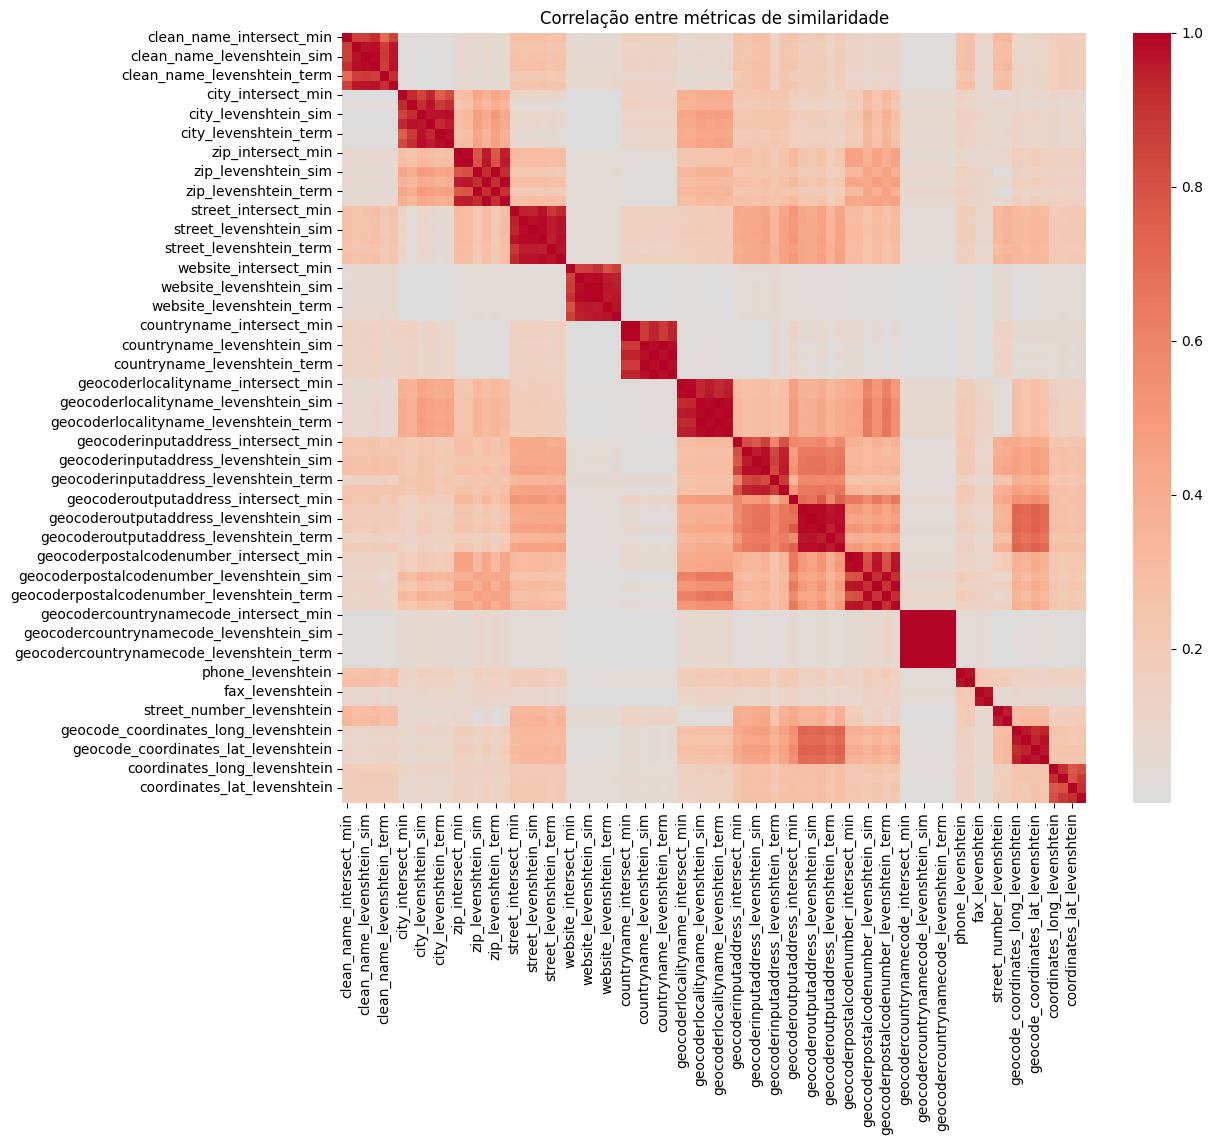

In [5]:
#Verificação de Atributos Técnicos ou Redundantes

#Selecionando colunas de similaridade:
cols_sim = [c for c in df.columns if any(k in c for k in ['intersect', 'levenshtein', 'trigram'])]

#Matriz de Correlação
corr_matrix = df[cols_sim].corr().abs()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlação entre métricas de similaridade')
plt.show()

In [6]:
#Verificação de Variaveis com alta corerlação

# Selecionar apenas as colunas numéricas
df_numeric = df.select_dtypes(include=['float64', 'int64']).copy()

# Calcular correlação
corr_matrix = df_numeric.corr().abs()

# Obter pares altamente correlacionados
threshold = 0.85
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'Variável 1', 'level_1': 'Variável 2', 0: 'Correlação'})
)

# Filtrar apenas as correlações fortes
high_corr = corr_pairs[corr_pairs['Correlação'] > threshold].sort_values(by='Correlação', ascending=False)

pd.set_option('display.max_rows', None)  # Mostrar todas as linhas

print("Pares de variáveis altamente correlacionadas (> 0.85):")
print(high_corr)

itables.show(high_corr)

pd.reset_option('display.max_rows')  # Resetar a opção para o padrão

Pares de variáveis altamente correlacionadas (> 0.85):
                                     Variável 1  \
4225      geocodercountrynamecode_intersect_min   
4289    geocodercountrynamecode_levenshtein_sim   
4347   geocodercountrynamecode_levenshtein_term   
4258      geocodercountrynamecode_intersect_max   
4259      geocodercountrynamecode_intersect_max   
4226      geocodercountrynamecode_intersect_min   
2737                  countryname_intersect_min   
4319        geocodercountrynamecode_trigram_sim   
4318        geocodercountrynamecode_trigram_sim   
4260      geocodercountrynamecode_intersect_max   
4257      geocodercountrynamecode_intersect_max   
4290    geocodercountrynamecode_levenshtein_sim   
4229      geocodercountrynamecode_intersect_min   
4228      geocodercountrynamecode_intersect_min   
4288    geocodercountrynamecode_levenshtein_sim   
4227      geocodercountrynamecode_intersect_min   
2924                    countryname_trigram_sim   
4088       geocoderpostalco

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [7]:
#Everificando exemplo de Correlação

cols = [
    "clean_name_intersect_min",
    "clean_name_intersect_max",
    "clean_name_levenshtein_sim",
    "clean_name_trigram_sim",
    "clean_name_levenshtein_term",
    "clean_name_trigram_term"
]

# Calcula a matriz de correlação
corr = df[cols].corr()

print("Correlação entre métricas de similaridade para 'clean_name':")
itables.show(corr)

Correlação entre métricas de similaridade para 'clean_name':


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [8]:
#Verificando Exemplo de Correlação 2
cols = [
    "phone_diff",
    "phone_levenshtein",
    "phone_trigram",
    "phone_equality"
]

# Calcula a matriz de correlação
corr = df[cols].corr()

print("Correlação entre métricas de similaridade para 'phone':")
itables.show(corr)

Correlação entre métricas de similaridade para 'phone':


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [9]:
#Verificando coorelação entre as variaveis de coordenadas
cols = [
    "coordinates_long_diff","coordinates_long_trigram","coordinates_long_equality",
    "coordinates_lat_diff","coordinates_lat_trigram","coordinates_lat_equality",
    "coordinates_diff"
]
# Calcula a matriz de correlação
corr = df[cols].corr()
print("Correlação entre métricas de similaridade para 'coordinates':")
itables.show(corr)

Correlação entre métricas de similaridade para 'coordinates':


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


#### Informações Retiradas:

1. Ex.: geocodercountrynamecode_intersect_min ↔ …_intersect_max ↔ …_levenshtein_sim/term ↔ …_trigram_(sim/term) aparecem com 1,000 diversas vezes. Na prática, qualquer uma dessas já representa o grupo.

2. Blocos de geocoder(locality/input/output address) e geocoderpostalcodenumber_* explodem a dimensionalidade sem ganhar informação nova — todos com 0,95–0,99 entre si.

3. Text matching geral é colinear. ara clean_name, city, zip, street, website, countryname: levenshtein ↔ trigram ↔ intersect têm 0,90+ em várias combinações. É esperado: são formas distintas de mensurar similaridade textual.
4. coordinates_long_* e coordinates_lat_* (e suas versões geocode_*) têm correlações altas entre diffs e n-gram/levenshtein (0,90–0,98) e até entre igualdades de lat/long (≈0,986). Faz sentido: quando longitude “bate”, latitude quase sempre “bate” também.
5. phone_diff, phone_levenshtein, phone_trigram e equivalentes de fax_* surgem com 0,90–0,97: outro bloco redundante.

#### Decisões

1. Prioridade a Trigram sobre Levenshtein pois no contexto de matching de nomes, endereços etc., o trigram costuma ser mais robusto para dados ruidosos e nomes próprios, enquanto levenshtein é melhor para detectar pequenas edições.
Se for escolher só um, trigram costuma ser mais útil para matching de texto real, especialmente em nomes e endereços.

2. Prioridade a Including pois including tende a ser mais útil para matching de registros, pois captura mais casos reais de similaridade.

3. Remoção de: *_intersect_min/max, _levenshtein_term, _trigram_term pois Essas métricas são altamente correlacionadas com as principais (*_levenshtein_sim e *_trigram_sim), não agregam informação nova relevante e aumentam a dimensionalidade do dataset, podendo prejudicar o modelo (overfitting, complexidade desnecessária). 

A ideia então é **manter** sempre os Trigrams (Se existentes) E os Includings (Se existentes) de cada familia.


In [10]:
#Copia do Dataframe
df_filtrado = df.copy()

#Colunas já definidas como redundantes
padroes_remocao = [
    "_intersect_min",
    "_intersect_max",
    "_levenshtein_term",
    "_trigram_term"
]

#Remoção
colunas_remover = [col for col in df_filtrado.columns if any(p in col for p in padroes_remocao)]

df_filtrado.drop(columns=colunas_remover, inplace=True, errors='ignore')
print(f"Removidas {len(colunas_remover)} colunas redundantes.")
print(f"DataFrame agora tem {df_filtrado.shape[1]} colunas.")

itables.show(df_filtrado)

Removidas 44 colunas redundantes.
DataFrame agora tem 76 colunas.


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [11]:
# Agrupando por famílias de atributos, separando coordinates_long, coordinates_lat e coordinates_diff
familias = {}
for col in df_filtrado.columns:
    if "_" in col:
        familia = col.split("_")[0]
        familias.setdefault(familia, []).append(col)

for familia, colunas in familias.items():
    print(f"Família: {familia}, Colunas: {colunas}")

print(f"Total de famílias: {len(familias)}")

Família: clean, Colunas: ['clean_name_levenshtein_sim', 'clean_name_trigram_sim', 'clean_name_including', 'clean_name_equality']
Família: city, Colunas: ['city_levenshtein_sim', 'city_trigram_sim', 'city_including', 'city_equality']
Família: zip, Colunas: ['zip_levenshtein_sim', 'zip_trigram_sim', 'zip_including', 'zip_equality']
Família: street, Colunas: ['street_levenshtein_sim', 'street_trigram_sim', 'street_including', 'street_equality', 'street_number_diff', 'street_number_levenshtein', 'street_number_trigram', 'street_number_equality']
Família: website, Colunas: ['website_levenshtein_sim', 'website_trigram_sim', 'website_including', 'website_equality']
Família: countryname, Colunas: ['countryname_levenshtein_sim', 'countryname_trigram_sim', 'countryname_including', 'countryname_equality']
Família: geocoderlocalityname, Colunas: ['geocoderlocalityname_levenshtein_sim', 'geocoderlocalityname_trigram_sim', 'geocoderlocalityname_including', 'geocoderlocalityname_equality']
Família: g

# Limpeza de Dados

In [12]:
#Aplicando prioridades de Seleção
colunas_selecionadas = []

for familia, colunas in familias.items():
    #Trigram
    trigram_cols = [c for c in colunas if 'trigram' in c]
    if trigram_cols:
        colunas_selecionadas.append(trigram_cols[0])  # Seleciona a primeira coluna trigram

    #Levenshtein (Caso não tenha Trigram)
    elif not trigram_cols:
        levenshtein_cols = [c for c in colunas if 'levenshtein' in c]
        if levenshtein_cols:
            colunas_selecionadas.append(levenshtein_cols[0])  # Seleciona a primeira coluna levenshtein

    #Including (sempre adiciona se existir)
    including_cols = [c for c in colunas if 'including' in c]
    if including_cols:
        colunas_selecionadas.append(including_cols[0])  # Seleciona a primeira coluna including

    # Se não houver trigram/levenshtein/including, tenta equality ou diff
    else:
        equality_cols = [c for c in colunas if 'equality' in c]
        diff_cols = [c for c in colunas if 'diff' in c]
        if equality_cols:
            colunas_selecionadas.append(equality_cols[0])
        elif diff_cols:
            colunas_selecionadas.append(diff_cols[0])

#Variavel alvo (O NOME da Classe Foi Removido pois ele é redundante com "Clas num" e serviu mais para entendimento)
colunas_selecionadas += ['Class_num']

df_selecionado = df_filtrado[colunas_selecionadas].copy()

#Alteração de:
#website_including, countryname_including, geocoderlocalityname_including, 
# geocoderimputaddress_including, geocoderoutputaddress_including, geocodercountrynamecode_including, 
# fax_equality e coordinates_long_equality
#Para numeros (1, 2 e 3) ao enves de bits (b'1', 'b'2' e b'3')

cols_to_int = [
    "website_including",
    "countryname_including",
    "geocoderlocalityname_including",
    "geocoderinputaddress_including",
    "geocoderoutputaddress_including",
    "geocodercountrynamecode_including",
    "fax_equality",
    "coordinates_long_equality",
    "geocode_coordinates_long_equality"
]
for col in cols_to_int:
    if col in df_selecionado.columns:
        def to_int(x):
            if isinstance(x, bytes):
                return int(x.decode('utf-8'))
            elif isinstance(x, str) and x.startswith("b'") and x.endswith("'"):
                # Remove the b'' and convert the inside to int
                return int(x[2:-1])
            else:
                return int(x)
        df_selecionado[col] = df_selecionado[col].apply(to_int)
        df_selecionado[col] = df_selecionado[col].astype(int)

#Retirando ultima redundância
df_selecionado = df_selecionado.drop(columns=['geocode_coordinates_long_equality'], errors='ignore')

#Verificando o DataFrame Final
print(f"\nMantidas {len(df_selecionado.columns)} colunas finais.")
print(df_selecionado.columns.tolist())
itables.show(df_selecionado)


Mantidas 30 colunas finais.
['clean_name_trigram_sim', 'clean_name_including', 'city_trigram_sim', 'city_including', 'zip_trigram_sim', 'zip_including', 'street_trigram_sim', 'street_including', 'website_trigram_sim', 'website_including', 'countryname_trigram_sim', 'countryname_including', 'geocoderlocalityname_trigram_sim', 'geocoderlocalityname_including', 'geocoderinputaddress_trigram_sim', 'geocoderinputaddress_including', 'geocoderoutputaddress_trigram_sim', 'geocoderoutputaddress_including', 'geocoderpostalcodenumber_trigram_sim', 'geocoderpostalcodenumber_including', 'geocodercountrynamecode_trigram_sim', 'geocodercountrynamecode_including', 'phone_trigram', 'phone_equality', 'fax_trigram', 'fax_equality', 'geocode_coordinates_long_trigram', 'coordinates_long_trigram', 'coordinates_long_equality', 'Class_num']


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [13]:
df_selecionado.to_csv('C:\\Users\\mateu\\Arquivos de Programas Faculdade\\Repositorios\\DataMining-CRISP-DM-The-Nomao-Problem\\data\\processed\\nomao_selecionado.csv', index=False)

In [14]:
print("✅ 120 variáveis originais,\n"
    "🧹 44 removidas por regra (_intersect, _term)\n"
    "🎯 16 famílias representadas (trigram/levenshtein)\n"
    "📉 31 features finais mantidas")

✅ 120 variáveis originais,
🧹 44 removidas por regra (_intersect, _term)
🎯 16 famílias representadas (trigram/levenshtein)
📉 31 features finais mantidas


### O que foi definido.

Estrategia usada:
1. Filter Based --> Conhecimento do domínio foi usado para decidir por exemplo que Triggram é mais Robusto que Levenstein
2. Statistics Based --> As redundâncias foram análisadas e tambem retiradas com análise numerica. (OS com correlação > 0,85)


Ainda há 0 pares com correlação > 0.85.
Series([], dtype: float64)


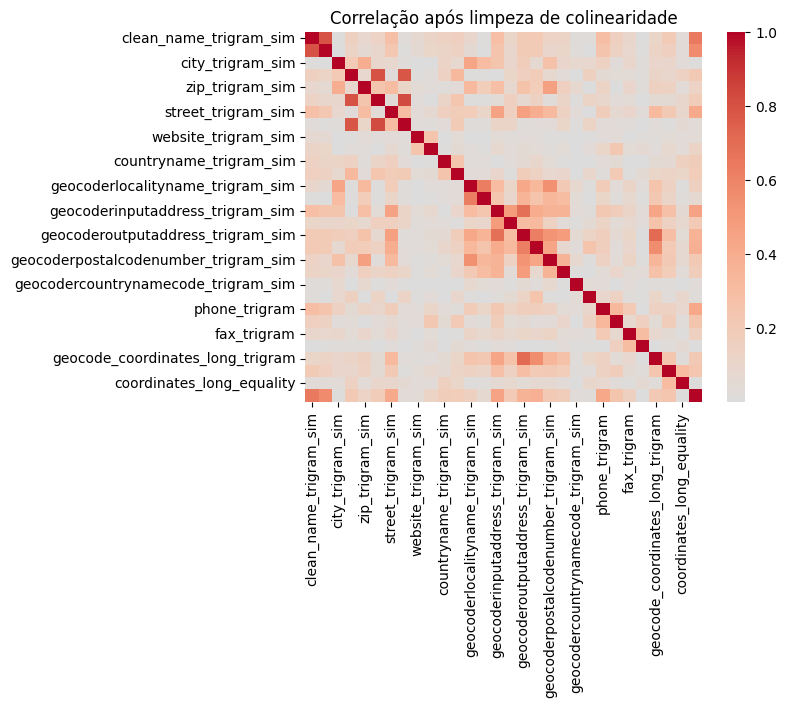


Lista de pares de colunas com correlação > 0.85:


In [15]:
#Validação da colinearidade Residual

corr = df_selecionado.select_dtypes('number').corr().abs()
high_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
redundantes = high_corr[high_corr > 0.85]

print(f"\nAinda há {len(redundantes)} pares com correlação > 0.85.")
print(redundantes.sort_values(ascending=False).head(10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlação após limpeza de colinearidade")
plt.show()

# Gerar lista dos pares altamente correlacionados
lista_redundantes = list(redundantes.index)
print("\nLista de pares de colunas com correlação > 0.85:")
for par in lista_redundantes:
    print(par)

### Treino ANTES da Construção de Dados

----------------------------------------------------
🔍 Relatório de Classificação:
               precision    recall  f1-score   support

Não Duplicado       0.93      0.93      0.93      1969
    Duplicado       0.97      0.97      0.97      4924

     accuracy                           0.96      6893
    macro avg       0.95      0.95      0.95      6893
 weighted avg       0.96      0.96      0.96      6893

----------------------------------------------------
ROC-AUC Score: 0.9911


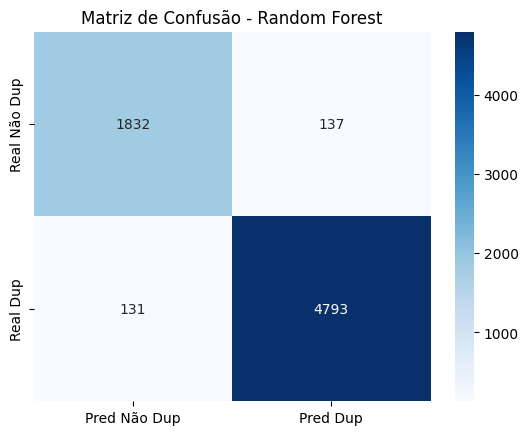

Validação cruzada (ROC-AUC): 0.9898 ± 0.0006


In [16]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np

# -------------------------------
# 1️⃣ Separar variáveis numéricas e alvo
# -------------------------------
X = df_selecionado.select_dtypes(include=['float64', 'int64']).drop(columns=['Class_num'], errors='ignore')
y = df_selecionado['Class_num']

# -------------------------------
# 2️⃣ Split treino-teste
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 4️⃣ Modelo de baseline — Random Forest (robusto para features correlacionadas)
# -------------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced_subsample',
    n_jobs=-1
)
rf.fit(X_train, y_train)

# -------------------------------
# 5️⃣ Avaliação
# -------------------------------
y_pred = rf.predict(X_test)
probs = rf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, probs)

print("----------------------------------------------------")
print("🔍 Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Não Duplicado', 'Duplicado']))
print("----------------------------------------------------")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Não Dup', 'Pred Dup'], yticklabels=['Real Não Dup', 'Real Dup'])
plt.title("Matriz de Confusão - Random Forest")
plt.show()

# -------------------------------
# 6️⃣ Validação cruzada para robustez
# -------------------------------
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
print(f"Validação cruzada (ROC-AUC): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# Construção de Dados

### Ideias

1. Média de similaridade de texto
2. Metrica se ambos os endereços estão incluidos
3. Normalização e Codificação:
    É Necessário escalar


In [17]:
#Metrica de Similaridade de Texto 

df_selecionado['avg_text_similarity'] = df_selecionado[['clean_name_trigram_sim', 'city_trigram_sim', 'street_trigram_sim', 'zip_trigram_sim']].mean(axis=1)

#Metrica de Endereços

df_selecionado['both_address_included'] = ((df_selecionado['street_including'] == 2) & (df_selecionado['zip_including'] == 2)).astype(int)

itables.show(df_selecionado[['avg_text_similarity', 'both_address_included']])
itables.show(df_selecionado)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


###  Treinamento pós construção de dados

----------------------------------------------------
🔍 Relatório de Classificação:
               precision    recall  f1-score   support

Não Duplicado       0.93      0.93      0.93      1969
    Duplicado       0.97      0.97      0.97      4924

     accuracy                           0.96      6893
    macro avg       0.95      0.95      0.95      6893
 weighted avg       0.96      0.96      0.96      6893

----------------------------------------------------
ROC-AUC Score: 0.9908


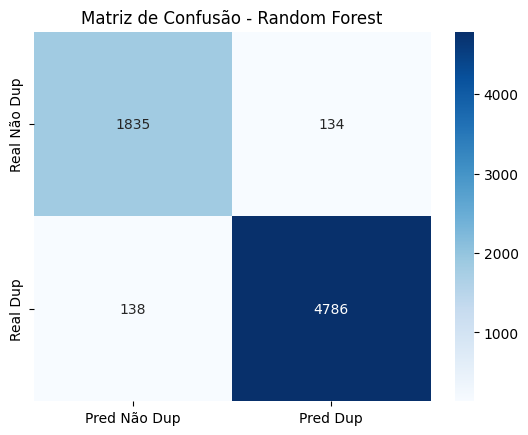

Validação cruzada (ROC-AUC): 0.9891 ± 0.0008


In [18]:
# -------------------------------
# 1️⃣ Separar variáveis numéricas e alvo
# -------------------------------
X = df_selecionado.select_dtypes(include=['float64', 'int64']).drop(columns=['Class_num'], errors='ignore')
y = df_selecionado['Class_num']

# -------------------------------
# 2️⃣ Split treino-teste
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 4️⃣ Modelo de baseline — Random Forest (robusto para features correlacionadas)
# -------------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced_subsample',
    n_jobs=-1
)
rf.fit(X_train, y_train)

# -------------------------------
# 5️⃣ Avaliação
# -------------------------------
y_pred = rf.predict(X_test)
probs = rf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, probs)

print("----------------------------------------------------")
print("🔍 Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Não Duplicado', 'Duplicado']))
print("----------------------------------------------------")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Não Dup', 'Pred Dup'], yticklabels=['Real Não Dup', 'Real Dup'])
plt.title("Matriz de Confusão - Random Forest")
plt.show()

# -------------------------------
# 6️⃣ Validação cruzada para robustez
# -------------------------------
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
print(f"Validação cruzada (ROC-AUC): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# Formatação dos Dados

In [19]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

colunas_categoricas = [col for col in df_selecionado if df_selecionado[col].name.endswith('including') or df_selecionado[col].name.endswith('equality')]
print("Colunas categóricas identificadas para codificação ordinal:")
print(colunas_categoricas)

encoder = OrdinalEncoder()
df_selecionado[colunas_categoricas] = encoder.fit_transform(df_selecionado[colunas_categoricas])

itables.show(df_selecionado)

df_selecionado_sem_target = df_selecionado.drop(columns=['Class_num'], errors='ignore')

scaler = StandardScaler()
num_cols = df_selecionado_sem_target.select_dtypes('number').columns
df_Standard_scaled = pd.DataFrame(
    scaler.fit_transform(df_selecionado_sem_target[num_cols]),
    columns=num_cols
)

itables.show(df_Standard_scaled)

Colunas categóricas identificadas para codificação ordinal:
['clean_name_including', 'city_including', 'zip_including', 'street_including', 'website_including', 'countryname_including', 'geocoderlocalityname_including', 'geocoderinputaddress_including', 'geocoderoutputaddress_including', 'geocoderpostalcodenumber_including', 'geocodercountrynamecode_including', 'phone_equality', 'fax_equality', 'coordinates_long_equality']


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


### Treinamento pós-formatação dos dados

----------------------------------------------------
🔍 Relatório de Classificação:
               precision    recall  f1-score   support

Não Duplicado       0.93      0.93      0.93      1969
    Duplicado       0.97      0.97      0.97      4924

     accuracy                           0.96      6893
    macro avg       0.95      0.95      0.95      6893
 weighted avg       0.96      0.96      0.96      6893

----------------------------------------------------
ROC-AUC Score: 0.9910


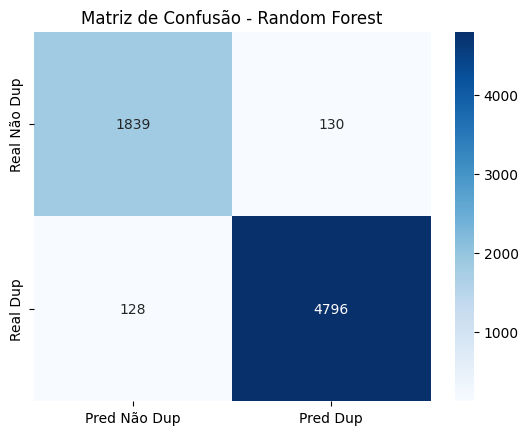

Validação cruzada (ROC-AUC): 0.9900 ± 0.0006


In [20]:

# -------------------------------
# 1️⃣ Separar variáveis numéricas e alvo
# -------------------------------
X = df_Standard_scaled.copy()
y = df_selecionado['Class_num']

# -------------------------------
# 2️⃣ Split treino-teste
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 4️⃣ Modelo de baseline — Random Forest (robusto para features correlacionadas)
# -------------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced_subsample',
    n_jobs=-1
)
rf.fit(X_train, y_train)

# -------------------------------
# 5️⃣ Avaliação
# -------------------------------
y_pred = rf.predict(X_test)
probs = rf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, probs)

print("----------------------------------------------------")
print("🔍 Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Não Duplicado', 'Duplicado']))
print("----------------------------------------------------")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Não Dup', 'Pred Dup'], yticklabels=['Real Não Dup', 'Real Dup'])
plt.title("Matriz de Confusão - Random Forest")
plt.show()

# -------------------------------
# 6️⃣ Validação cruzada para robustez
# -------------------------------
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
print(f"Validação cruzada (ROC-AUC): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


----------------------------------------------------
🔍 Relatório de Classificação:
               precision    recall  f1-score   support

Não Duplicado       0.94      0.93      0.93      1969
    Duplicado       0.97      0.98      0.97      4924

     accuracy                           0.96      6893
    macro avg       0.96      0.95      0.95      6893
 weighted avg       0.96      0.96      0.96      6893

----------------------------------------------------
ROC-AUC Score: 0.9910


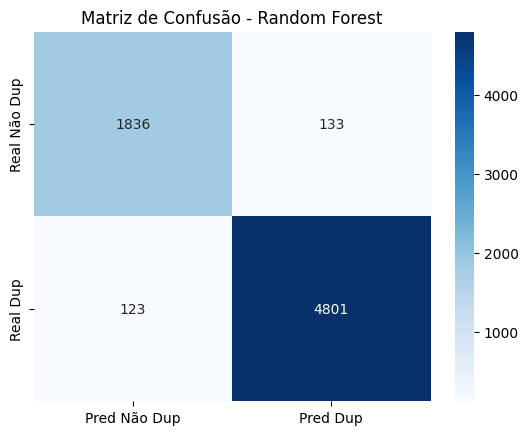

Validação cruzada (ROC-AUC): 0.9898 ± 0.0006


In [21]:

# -------------------------------
# 1️⃣ Separar variáveis numéricas e alvo
# -------------------------------
X = df_selecionado.select_dtypes(include=['float64', 'int64']).drop(columns=['Class_num'], errors='ignore')
y = df_selecionado['Class_num']

# -------------------------------
# 2️⃣ Split treino-teste
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 4️⃣ Modelo de baseline — Random Forest (robusto para features correlacionadas)
# -------------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced_subsample',
    n_jobs=-1
)
rf.fit(X_train, y_train)

# -------------------------------
# 5️⃣ Avaliação
# -------------------------------
y_pred = rf.predict(X_test)
probs = rf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, probs)

print("----------------------------------------------------")
print("🔍 Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Não Duplicado', 'Duplicado']))
print("----------------------------------------------------")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Não Dup', 'Pred Dup'], yticklabels=['Real Não Dup', 'Real Dup'])
plt.title("Matriz de Confusão - Random Forest")
plt.show()

# -------------------------------
# 6️⃣ Validação cruzada para robustez
# -------------------------------
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
print(f"Validação cruzada (ROC-AUC): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
